Two Qubit Control in Rydberg Blockade
=========================

TODO
- code the double bloch sphere 
- make visuals
- tune matt chow gate to the required phase accumulation for the CZ equivalent gate

We know that our $SU(2)$ ops on each qubit and a large enough interaction $V_{rr}$, we can think of the system as two block spheres. The action on the $\left| 00 \right>$ state can be ignored, and the $\left| 01 \right>$ and $\left| 10 \right>$ have the same evolution. This means the two states we can look at are $\left| 01 \right>$ and $\left| 11 \right>$ states:
$$
\hat{H}_{01} \rightarrow
\left[
    \begin{matrix}
        0 & \Omega/2 \\
        \Omega/2 & -\Delta
    \end{matrix} 
\right] \
\,
\text{and}
\,\,\,
\hat{H}_{11} \rightarrow
\left[
    \begin{matrix}
        0 & \Omega/\sqrt{2} \\
        \Omega/\sqrt{2} & -\Delta
    \end{matrix} 
\right]
$$

This means we still only get to really control the same three parameters ($\Omega$, $\Delta$, $\phi$), but now have three results we want to fix in place ($_{01}\bra{0}\ket{\psi{(T)}} = 1$, $_{11}\bra{0}\ket{\psi{(T)}} = 1$, $\xi_{11}-2\xi_{01}=\pi$).

In [1]:
# setting up stuff
using QuantumOptics
using LinearAlgebra

computational = SpinBasis(1//2)

I = identityoperator(computational)
σx = sigmax(computational)
σy = sigmay(computational)
σz = sigmaz(computational)
σ_vec = [σx, σy, σz];

down = spindown(computational)
up = spinup(computational)
;

Want to be able to represent a spin $\tfrac{1}{2}$ system so we can test the time evolution of different pulses. Our Hamiltonian can be controlled by a laser. A laser can be controlled by the intensity, frequency, and phase. While not exactly the same, these can be mapped to three parameters in our Hamiltonian:
$$
\text{intensity} \mapsto \Omega(t) \\
\text{frequency} \mapsto \Delta(t) \\
\text{phase} \mapsto \phi(t) 
$$
which appear in the Hamiltonian as follows:
$$
\hat{H}(\Delta(t), \Omega(t), \phi(t)) = \frac{-\Delta(t)}{2}\hat{1} 
    - \frac{-\Delta(t)}{2}\hat{\sigma}_z 
    + \frac{\Omega(t)}{2}
        (
            \cos{\phi(t)}\hat{\sigma}_x +
            \sin{\phi(t)}\hat{\sigma}_y
        )
    = -\frac{1}{2}\Delta(t)\hat{1} + \frac{1}{2}\tilde{\vec{\Omega}}(t) \cdot \hat{\vec{\sigma}}
$$

In [2]:
function twoLevelSysFromParameters(Ψ₀::StateVector, Δ::Function, Ω::Function, ϕ::Function, T::Real; number_of_reported_times::Int = 100)
    H(t, ignored) = Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 

    tspan = range(0, T, number_of_reported_times)
    tout, psi_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H)
    return tout, psi_t, t->H(t, nothing)
end

function rydberg_blockaded_system(Ψ₀::StateVector, Δ::Function, Ω::Function, ϕ::Function, T::Real; number_of_reported_times::Int = 100)
    H_01(t, ignored) = Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 
    H_11(t, ignored) = sqrt(2)*Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 

    tspan = range(0, T, number_of_reported_times)
    tout, psi01_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H_01)
    _,    psi11_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H_11)
    return tout, (psi01_t, t->H_01(t, nothing)), (psi11_t, t->H_11(t, nothing))
end

rydberg_blockaded_system (generic function with 1 method)

In [19]:
include("./Plotting.jl")
include("./Utils.jl")
using CairoMakie
using IJulia

Δ(t) = -1
Ω(t) = 1
ϕ(t) = 0
T=2π/sqrt(3)

filename01 = "./graphics/simple_double_bloch01.gif"
filename11 = "./graphics/simple_double_bloch11.gif"
tout, (psi01_t, H_01), (psi11_t, H_11) = rydberg_blockaded_system(down, Δ, Ω, ϕ, T)
save_bloch_animation(tout, psi01_t, 5, 24, filename01, title="|01>")
save_bloch_animation(tout, psi11_t, 5, 24, filename11, title="|11>")

display("text/html", """
<img src="$filename01" width=600>
<img src="$filename11" width=600>
""")


Fidelity measure
-----------------
We can repeat the gate that was done by the Sandians (Matt, Bethany, Saurabh, etc) which was inspired by the adiabatic gate but was faster. I will call this the "Inspired by Adiabtic" (IBA) gate in this notebook. 

I would like to define Fidelity of my implemented gate $\hat{U}$ as 
$$
4\mathscr{F} = Tr(\hat{C}_z \hat{U}) 
= \sum_i^{\{0, 1, r\}}\sum_j^{\{0, 1, r\}} \bra{ij} \hat{C}_z \hat{U} \ket{ij} 
$$

Now I assume we start in a computational state $\{\ket{00}, \ket{01}, \ket{10}, \ket{11}\}$ and we don't want to count any population that ended outside of our computational basis towards our fidelity.
$$
= \sum_i^{\{0, 1\}}\sum_j^{\{0, 1\}} \bra{ij} \hat{C}_z \hat{U} \ket{ij} 
$$

we also assume nothing happens to $\ket{00}$ and the exact same action happens to $\ket{01}$ and $\ket{10}$:
$$
= \bra{00} \hat{C}_z \hat{U} \ket{00} + \bra{01} \hat{C}_z \hat{U} \ket{01} + \bra{10} \hat{C}_z \hat{U} \ket{10} + \bra{11} \hat{C}_z \hat{U} \ket{11} \\
= 1 + 2\bra{01} \hat{C}_z \hat{U} \ket{01} + \bra{11} \hat{C}_z \hat{U} \ket{11} \\
$$

Now there is a trickyness here. $\hat{C}_z$ in our equation isn't exactly the control-$Z$ that we know and love, just up to local $SU(2)$ ops on single qubits. This means the phases needed must satisfy $$2\phi_{01} - \phi_{11} = \pi \mod 2\pi$$ 
To use this we would have to define a specific $\phi_{10}$ we want to implement and see how good our fidelity is compared to that. For now I am going to claim that any gate that implements a control-$Z$ is goo enough by claiming that I can know what the value of $\phi_{01}$ is no matter what.
$$
= 1 + 2 \left|\bra{01} \hat{C}_z \hat{U} \ket{01} \right| + e^{\pi-2\phi_{01}}\bra{11} \hat{C}_z \hat{U} \ket{11} \\
= 1 + 2 \left|\bra{01} \hat{C}_z \hat{U} \ket{01} \right| + e^{\pi-2\phi_{01} + \phi_{11}} \left| \bra{11} \hat{C}_z \hat{U} \ket{11} \right| \\
$$ 

To explain, we always get full $00$ return, and if we have fill population return of both $01$ and $11$ in addition to 
$$
\pi-2\phi_{01} + \phi_{11} = 0 \mod 2\pi
$$
then we get a value of $4 \mathscr{F}=4$!

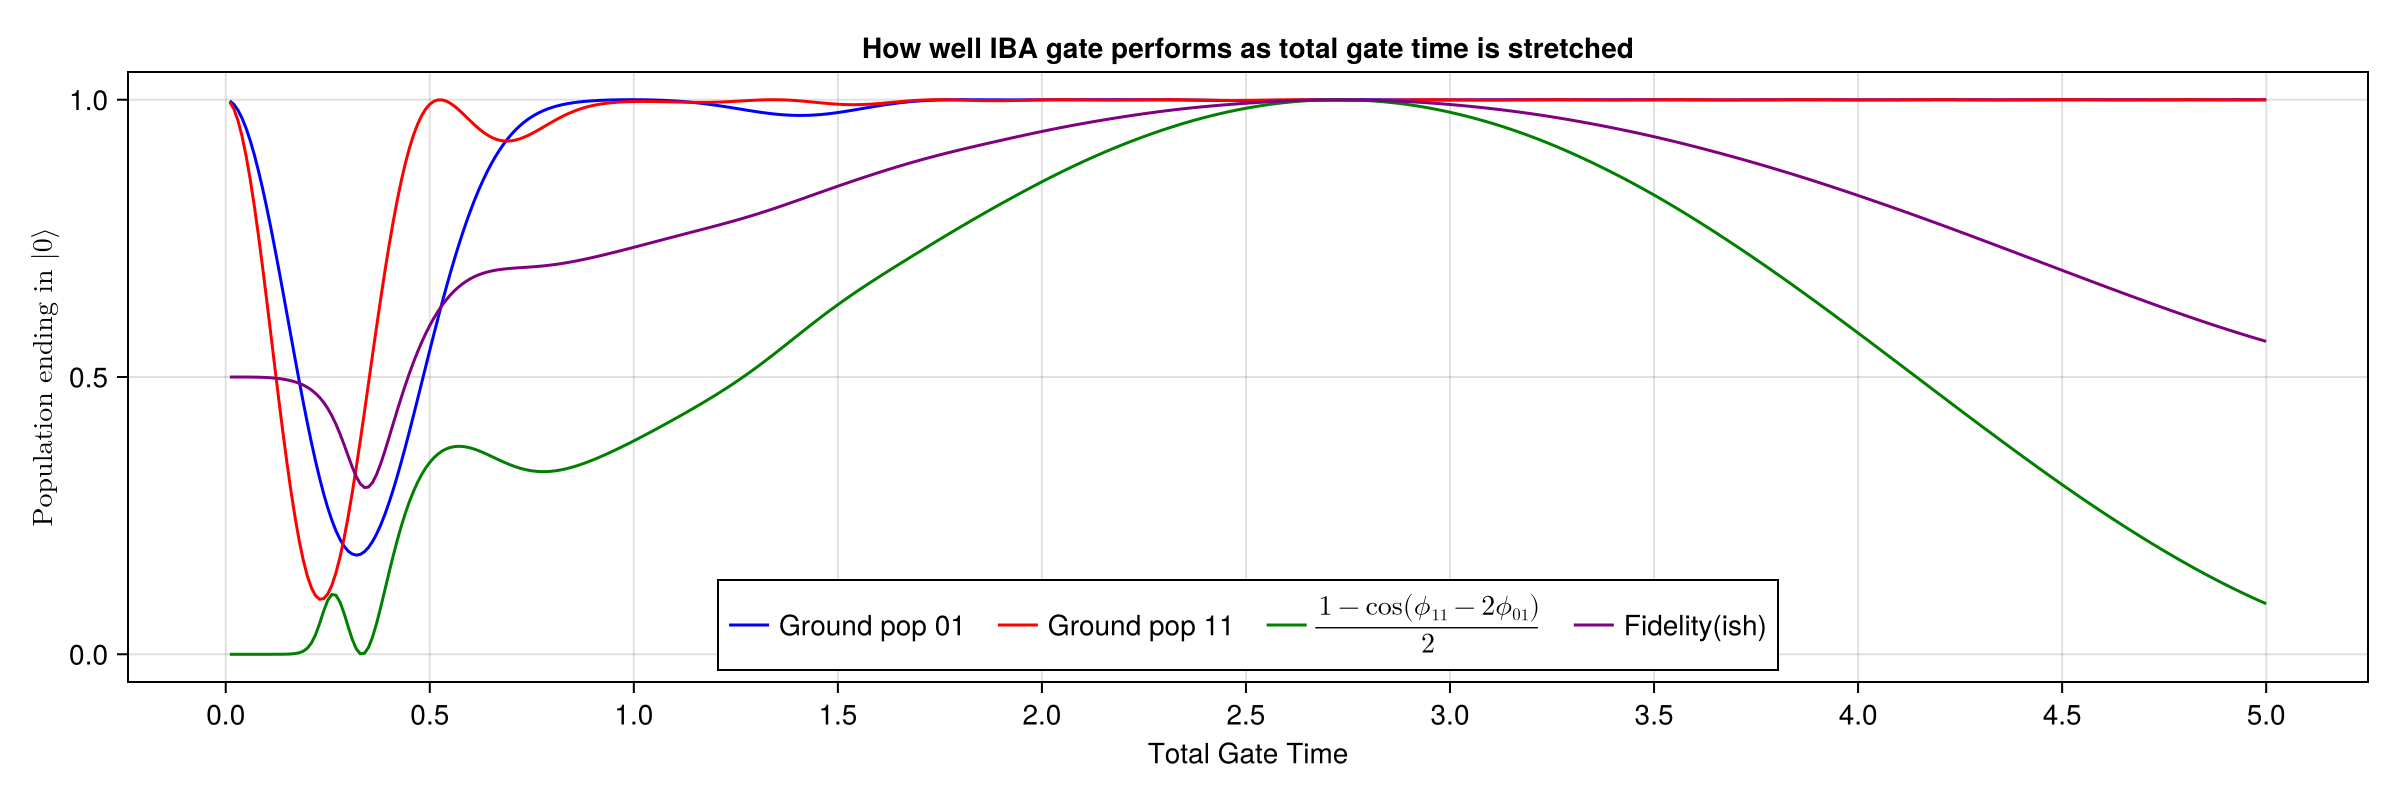

CairoMakie.Screen{IMAGE}


In [48]:
using Interpolations
using QuantumOptics
using CairoMakie

function iba_gate(T::Real, Ω_scaling=1)
    fudge_factor = 1.65 # this was not part of the original gate but is needed for the simulation to match the experimental data
    Ω_points = fudge_factor*2π .* [0.0, 0.412, 0.825, 1.237, 1.485, 1.485, 1.237, 0.825, 0.412, 0.0] #MHz I think
    Δ_points = 2π .* [4.08, 3.06, 2.04, 1.02, 0.408, 0.408, 1.02, 2.04, 3.06, 4.08] #MHz I think

    ts = range(0, T, length(Ω_points))
    Δ(t) = cubic_spline_interpolation(ts, Δ_points)(t) # this could also be `Ω = cubic_spline_interpolation(ts, Ω_points)` ¯\_(ツ)_/¯
    Ω(t) = Ω_scaling * cubic_spline_interpolation(ts, Ω_points)(t) 
    ϕ(t) = 0

    (tout, psi_t, H) = twoLevelSysFromParameters(down, Δ, Ω, ϕ, T)
    return (tout, psi_t, H), (Δ, Ω, ϕ) # returns a lot of stuff but they are all useful
end


iterations = 500
tmin = 0.01
tmax = 5
Ts = range(tmin, tmax, iterations)

# plot the 
function ending_population_01(T::Real) 
    (tout, psi_t, H), (Δ, Ω, ϕ) = iba_gate(T, 1)
    return abs2(psi_t[end][2])
end
function ending_population_11(T::Real) 
    (tout, psi_t, H), (Δ, Ω, ϕ) = iba_gate(T, sqrt(2))
    return abs2(psi_t[end][2])
end
function phase_accum(T::Real)
    (tout, psi_t, H), (Δ, Ω, ϕ) = iba_gate(T, 1)
    ϕ_01 = angle(psi_t[end][2])
    (tout, psi_t, H), (Δ, Ω, ϕ) = iba_gate(T, sqrt(2))
    ϕ_11 = angle(psi_t[end][2])
    return (-cos(ϕ_11-2*ϕ_01)+1)/2
end
function fidelity(T::Real)
    (tout, psi_t, H), (Δ, Ω, ϕ) = iba_gate(T, 1)
    zero_inner_01 = abs(psi_t[end][2])
    ϕ_01 = angle(psi_t[end][2])
    (tout, psi_t, H), (Δ, Ω, ϕ) = iba_gate(T, sqrt(2))
    zero_inner_11 = abs(psi_t[end][2])
    ϕ_11 = angle(psi_t[end][2])
    F = abs((1+2*zero_inner_01+cis(ϕ_11 - 2*ϕ_01 - π)*zero_inner_11)/4)
    return F
end

# plotting
fig = Figure(size=(1200, 400))
ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
    title = "How well IBA gate performs as total gate time is stretched",
    xlabel = "Total Gate Time",
    ylabel = L"Population ending in $|0\rangle$",
    xticks = (0:0.5:tmax)
)

lines!(ax1, Ts, ending_population_01, color = :blue, label = "Ground pop 01")
lines!(ax1, Ts, ending_population_11, color = :red, label = "Ground pop 11")
lines!(ax1, Ts, phase_accum, color = :green, label = L"\frac{1-\cos(\phi_{11}-2\phi_{01})}{2}")
lines!(ax1, Ts, fidelity, color = :purple, label = "Fidelity(ish)")

axislegend(ax1, position = :cb, orientation = :horizontal)

display(fig)

That looks terrible, lets try to change the power. We multiply by some total factor uniformly over the pulse.

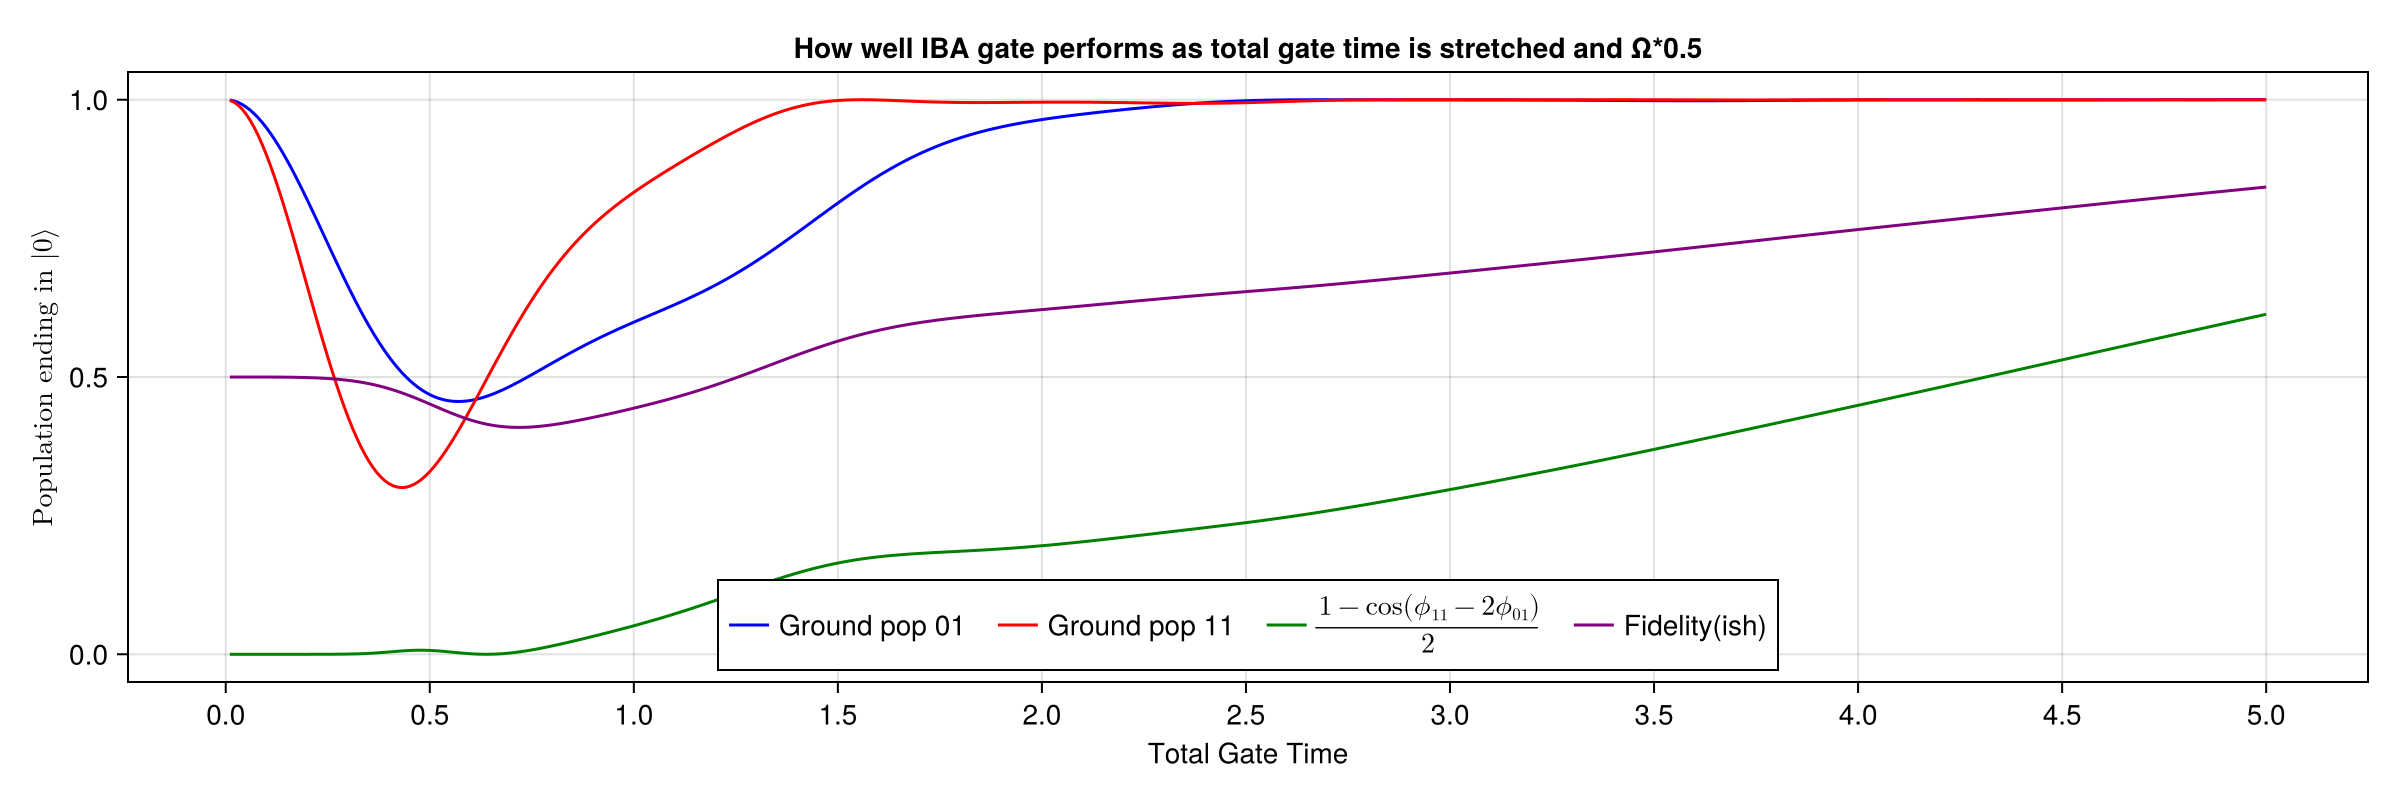

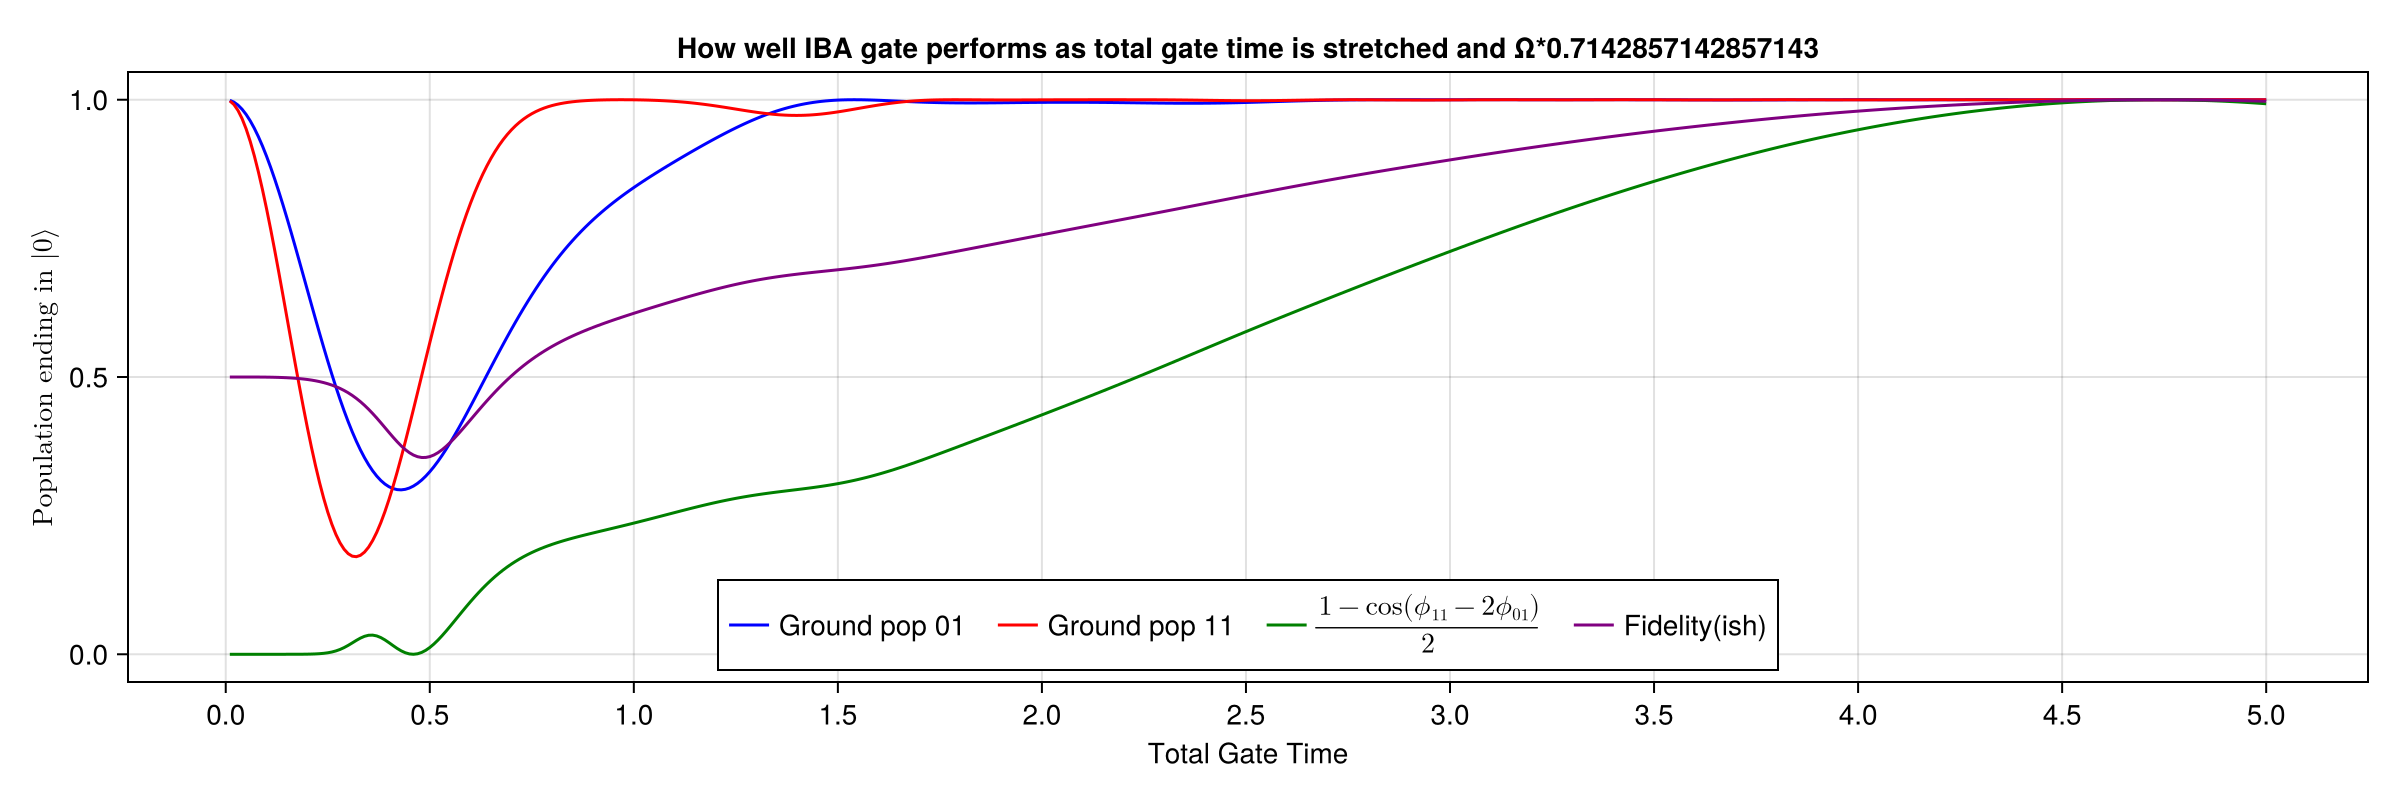

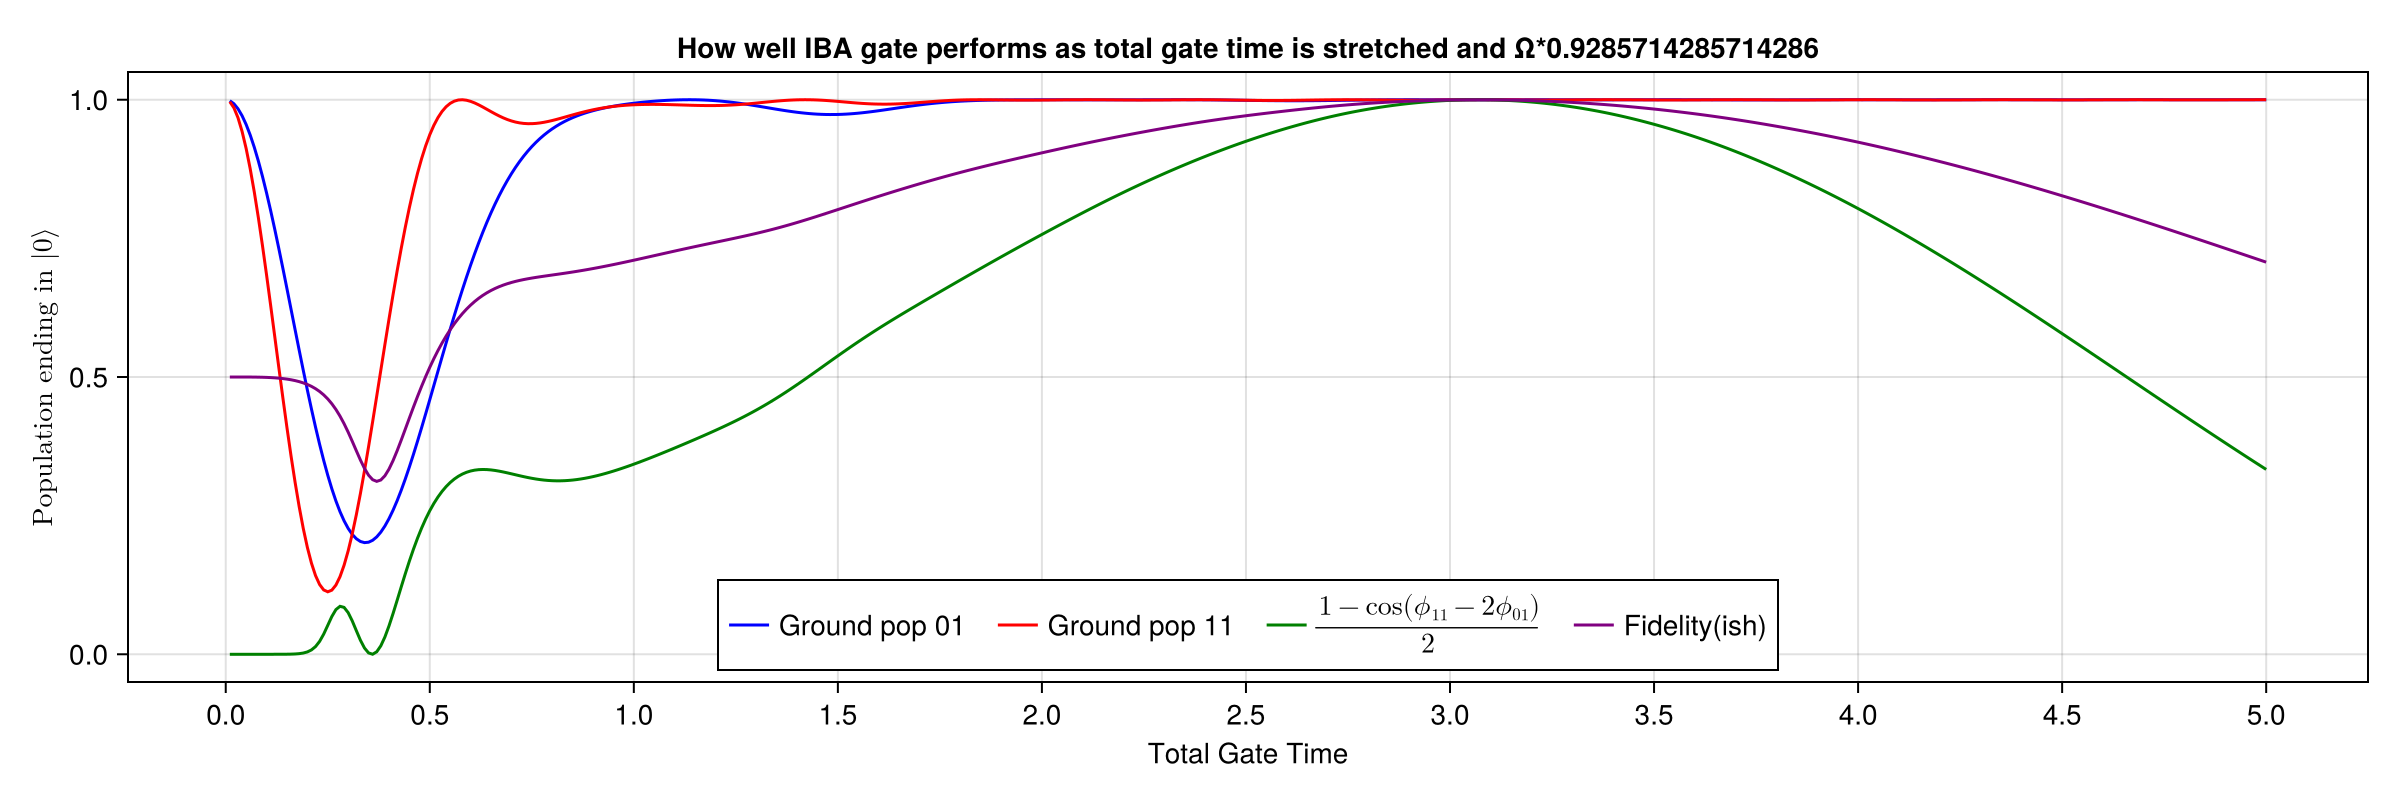

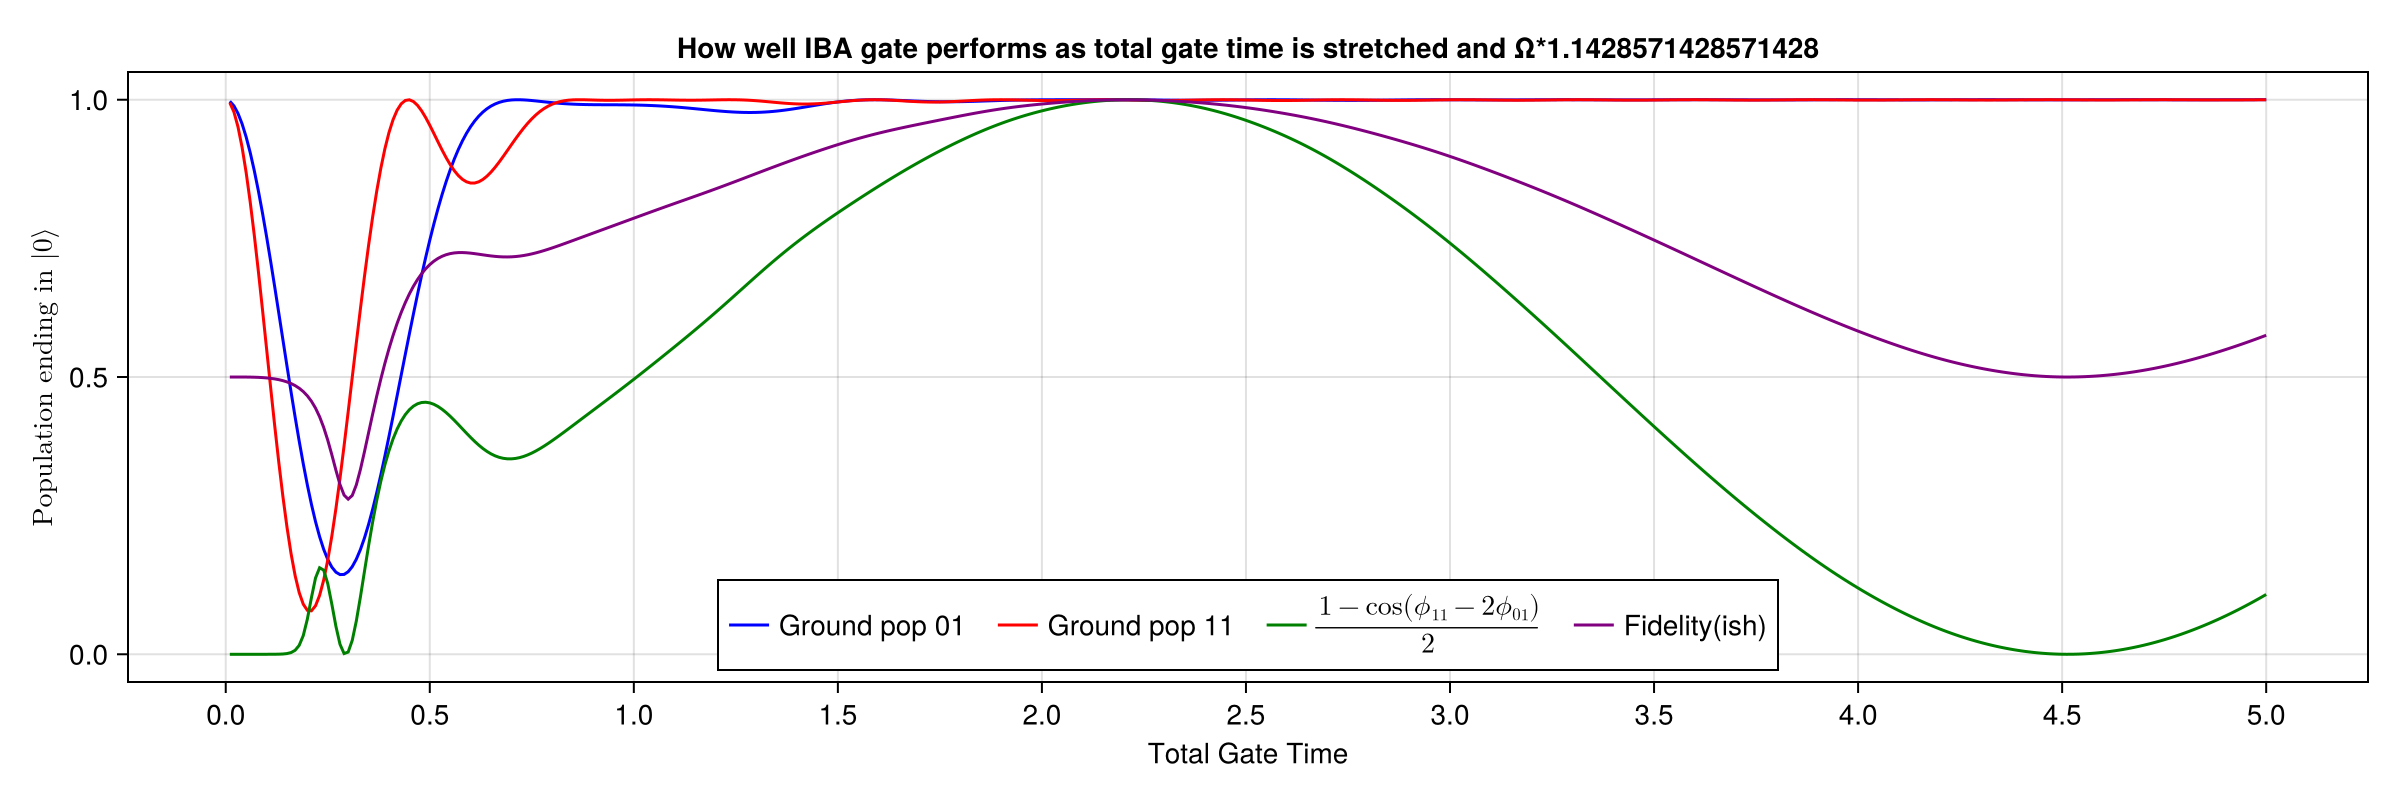

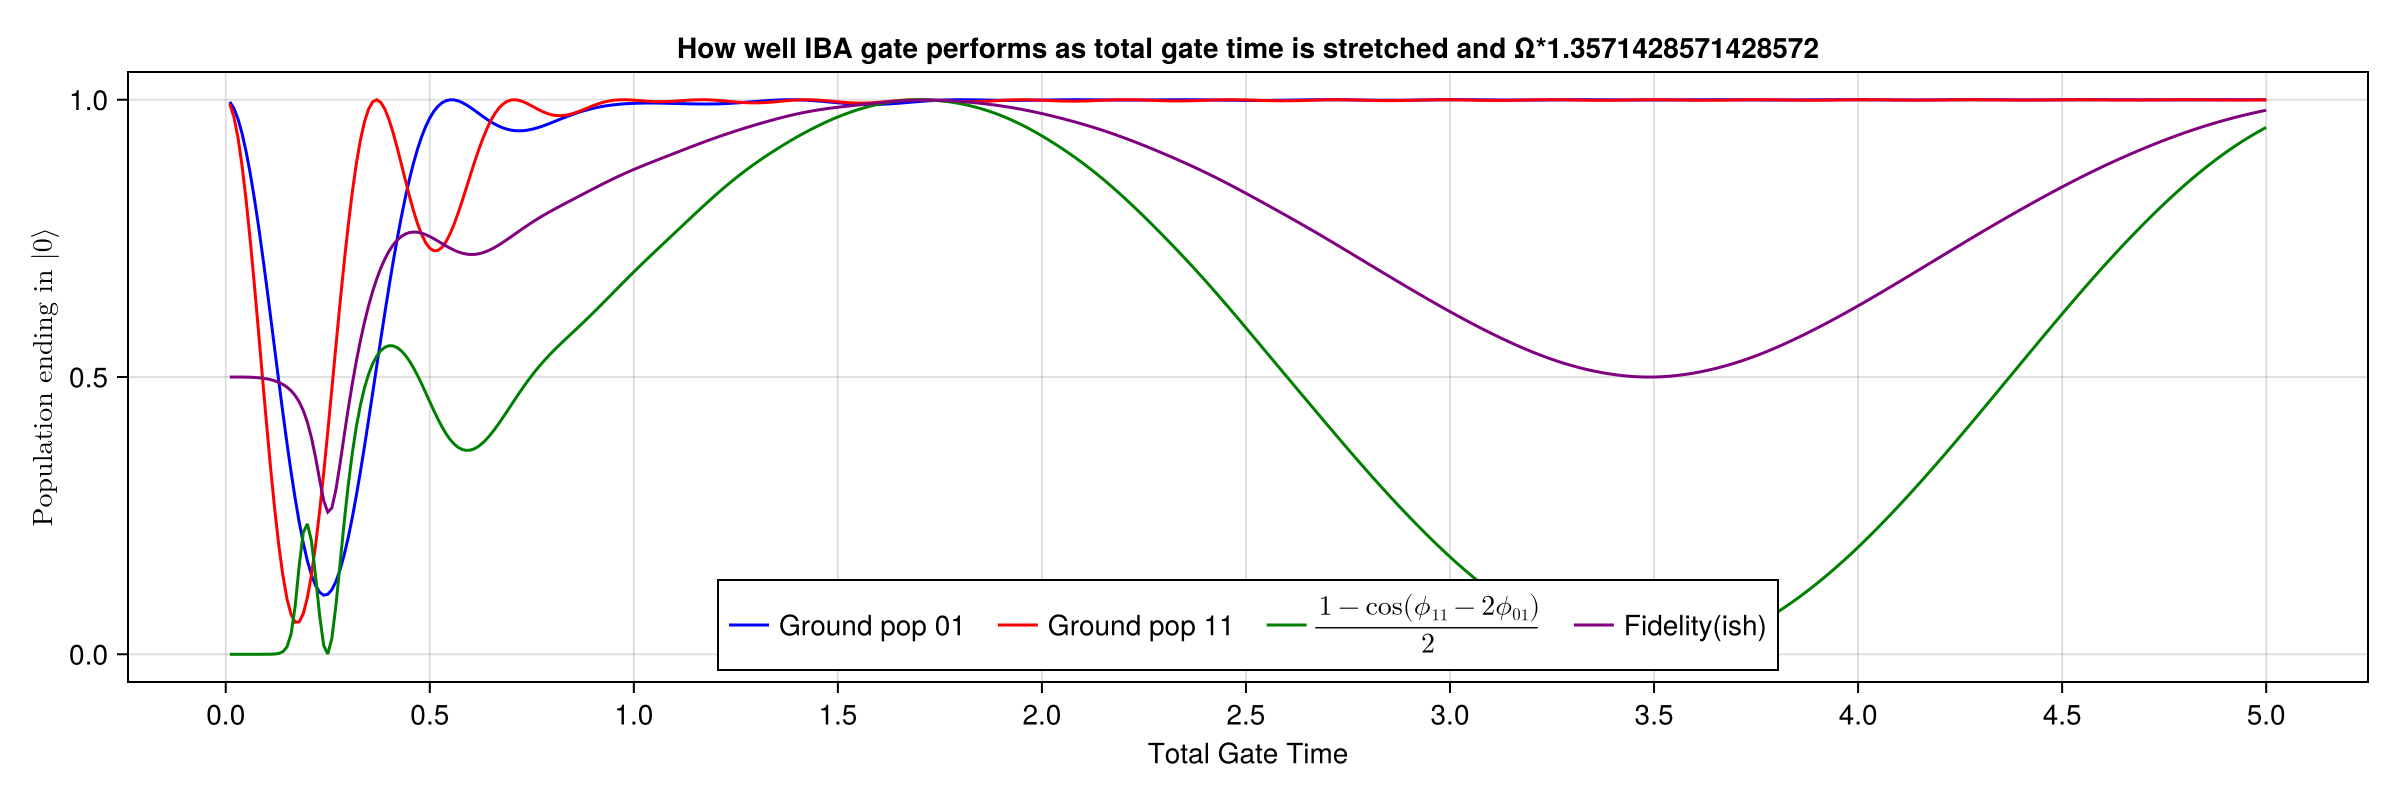

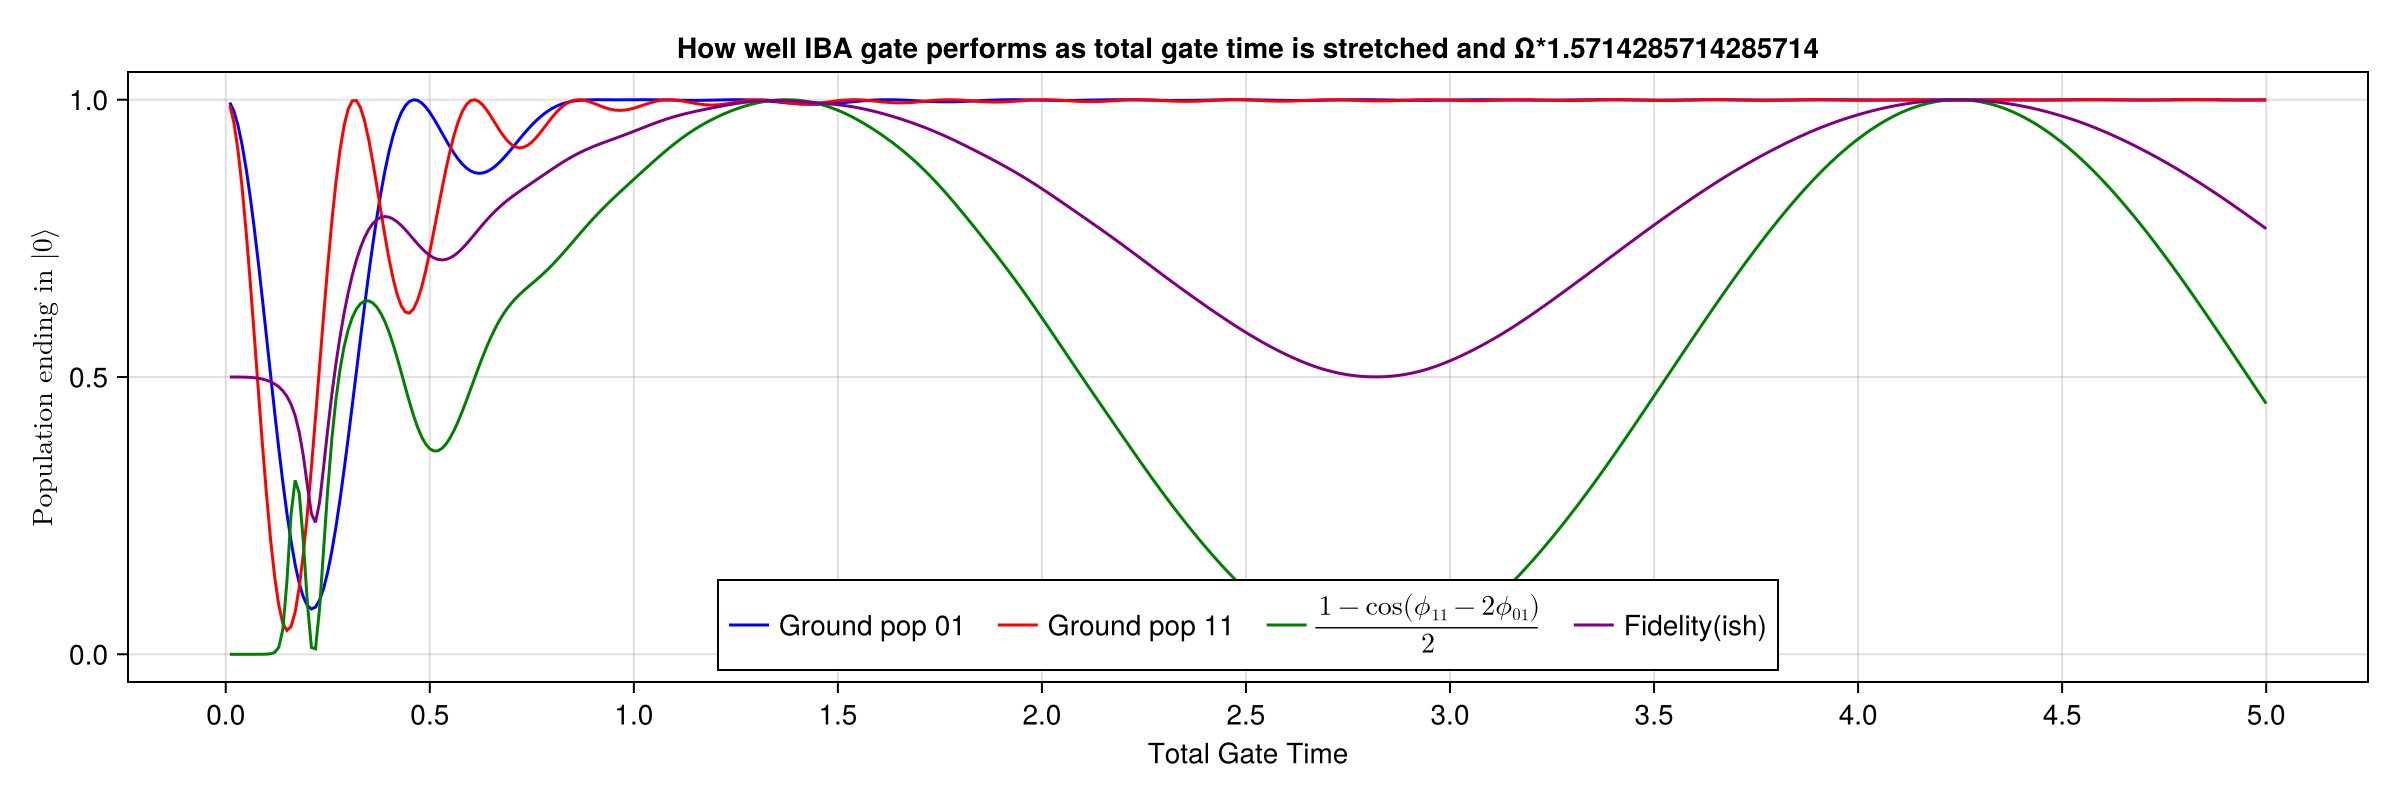

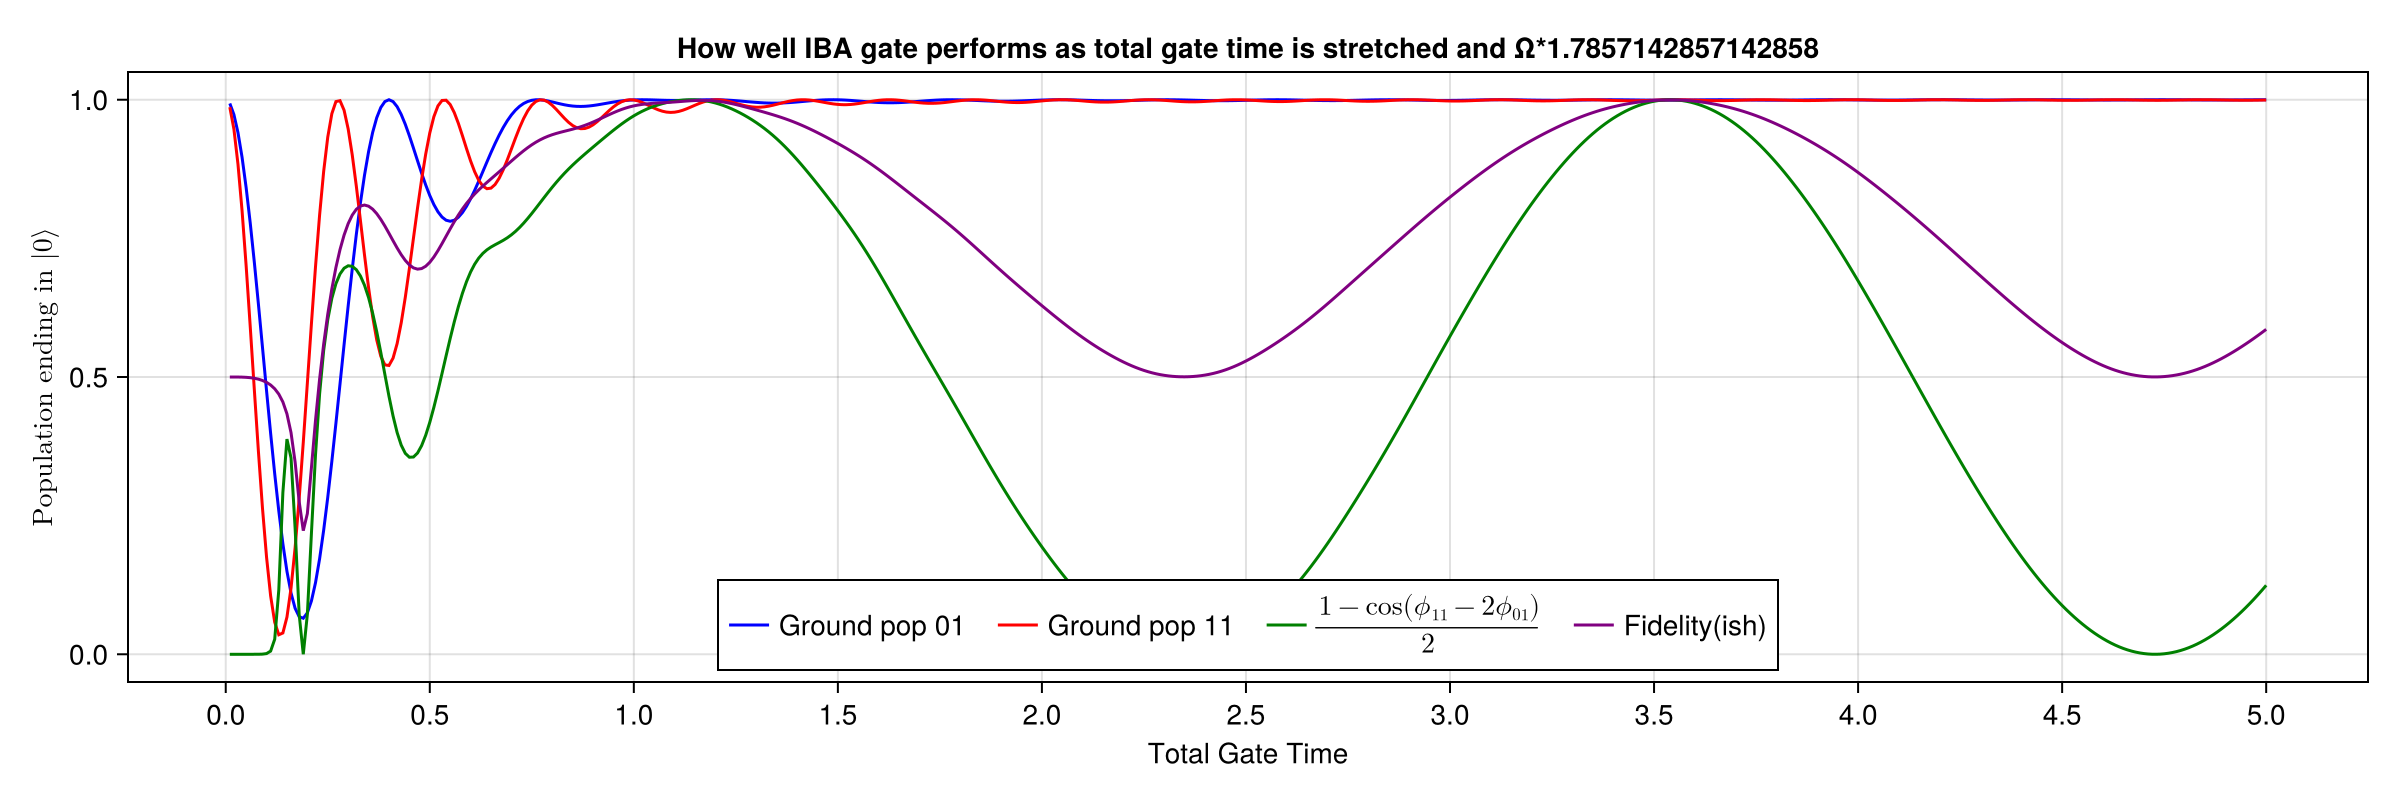

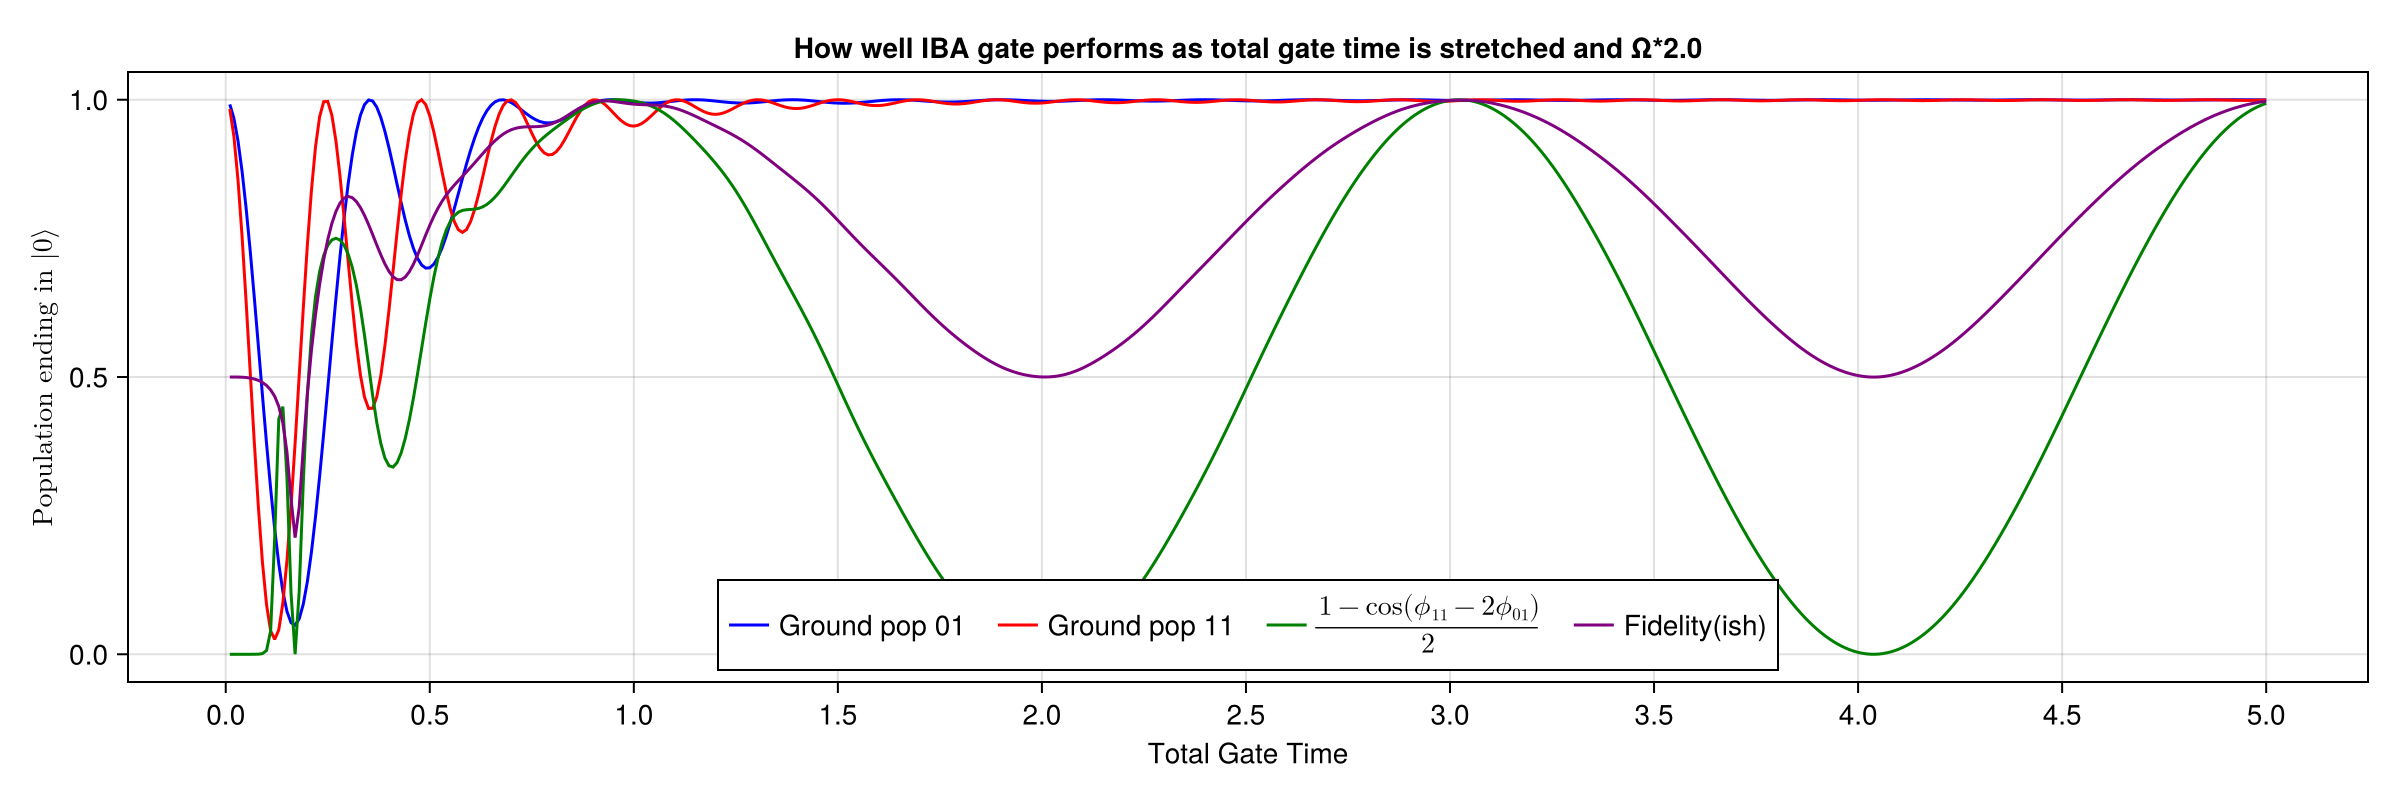

In [46]:
using Interpolations
using QuantumOptics
using CairoMakie

for Ω_multiplier in range(0.5, 2.0,8)
    iterations = 500
    tmin = 0.01
    tmax = 5
    Ts = range(tmin, tmax, iterations)

    iba_gate_new(t, Ω) = iba_gate(t, Ω*Ω_multiplier)

    # plot the 
    function ending_population_01(T::Real) 
        (tout, psi_t, H), (Δ, Ω, ϕ) = iba_gate_new(T, 1)
        return abs2(psi_t[end][2])
    end
    function ending_population_11(T::Real) 
        (tout, psi_t, H), (Δ, Ω, ϕ) = iba_gate_new(T, sqrt(2))
        return abs2(psi_t[end][2])
    end
    function phase_accum(T::Real)
        (tout, psi_t, H), (Δ, Ω, ϕ) = iba_gate_new(T, 1)
        ϕ_01 = angle(psi_t[end][2])
        (tout, psi_t, H), (Δ, Ω, ϕ) = iba_gate_new(T, sqrt(2))
        ϕ_11 = angle(psi_t[end][2])
        return (-cos(ϕ_11-2*ϕ_01)+1)/2
    end
    function fidelity(T::Real)
        (tout, psi_t, H), (Δ, Ω, ϕ) = iba_gate_new(T, 1)
        zero_inner_01 = abs(psi_t[end][2])
        ϕ_01 = angle(psi_t[end][2])
        (tout, psi_t, H), (Δ, Ω, ϕ) = iba_gate_new(T, sqrt(2))
        zero_inner_11 = abs(psi_t[end][2])
        ϕ_11 = angle(psi_t[end][2])
        F = abs((1+2*zero_inner_01+cis(ϕ_11 - 2*ϕ_01 - π)*zero_inner_11)/4)
        return F
    end

    # plotting
    fig = Figure(size=(1200, 400))
    ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
        title = "How well IBA gate performs as total gate time is stretched and Ω*$Ω_multiplier",
        xlabel = "Total Gate Time",
        ylabel = L"Population ending in $|0\rangle$",
        xticks = (0:0.5:tmax)
    )

    lines!(ax1, Ts, ending_population_01, color = :blue, label = "Ground pop 01")
    lines!(ax1, Ts, ending_population_11, color = :red, label = "Ground pop 11")
    lines!(ax1, Ts, phase_accum, color = :green, label = L"\frac{1-\cos(\phi_{11}-2\phi_{01})}{2}")
    lines!(ax1, Ts, fidelity, color = :purple, label = "Fidelity(ish)")

    axislegend(ax1, position = :cb, orientation = :horizontal)

    display(fig)
end

still utter garbage. Either the code is wrong or I am not using the correct values that were used in the lab. I will check with Saurabh to see if I can get the exact numbers used. 

From what I see it, looks like the phases fails to reach the desired relative values until a certain length of the gate. This goes to a shorter time as power is increased. The QSL improving as we have more power sounds like it could be correct. 

